# Neural Network Training

## Imports

In [ ]:
from pathlib import Path
import ctypes
import os
import site
from datetime import datetime

os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"

site_packages_dir = Path(site.getsitepackages()[0])
nvidia_root = site_packages_dir / "nvidia"
cuda_lib_dirs = [p for p in nvidia_root.rglob("*") if p.is_dir() and p.name in {"lib", "lib64"}]
for lib_dir in cuda_lib_dirs:
    for lib_file in sorted(lib_dir.glob("*.so*")):
        try:
            ctypes.CDLL(str(lib_file), mode=ctypes.RTLD_GLOBAL)
        except OSError:
            pass

import tensorflow as tf
from tensorflow import keras
from keras import layers, regularizers
import keras_tuner as kt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, balanced_accuracy_score, recall_score, precision_score, f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from enum import Enum
from dataclasses import dataclass

I0000 00:00:1773801875.814330  799556 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


## Helper Enums and Data Classes

In [2]:
class DIMENSION(Enum):
    K_9 = 9
    K_12 = 12
    K_21 = 21

class Classes(Enum):
    NO_DIABETES = 0
    PREDIABETES = 1
    DIABETES = 2

@dataclass
class DatasetSplit:
    X_train: pd.DataFrame
    y_train: pd.Series
    X_val: pd.DataFrame
    y_val: pd.Series
    X_test: pd.DataFrame
    y_test: pd.Series

@dataclass
class HyperParamVersion:
    learning_rate: float
    hidden_layers: int
    start_neurons: int
    dropout_rate: float
    l2_lambda: float
    epochs: int
    batch_size: int

class ValMacroF1Callback(keras.callbacks.Callback):
    def __init__(self, x_val, y_val_labels):
        super().__init__()
        self.x_val = x_val
        self.y_val_labels = np.asarray(y_val_labels)

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        y_val_pred = np.argmax(self.model.predict(self.x_val, verbose=0), axis=-1)
        logs["val_f1_macro"] = f1_score(self.y_val_labels, y_val_pred, average="macro", zero_division=0)

## Load Datasets

In [3]:
# Helper functions to load datasets
UNDERSAMPLING_DATASET = lambda k,type: Path(f"datasets/undersampling/undersampling_{type}_k{str(k)}.csv")
SMOTE_DATASET = lambda k,type: Path(f"datasets/oversampling/Smote{type}_k{str(k)}.csv")

base_dataset = pd.read_csv("datasets/BaseDataset.csv")
undersampling_datasets_train = {k: pd.read_csv(UNDERSAMPLING_DATASET(k.value, "train")) for k in DIMENSION}
undersampling_datasets_val = {k: pd.read_csv(UNDERSAMPLING_DATASET(k.value, "val")) for k in DIMENSION}
undersampling_datasets_test = {k: pd.read_csv(UNDERSAMPLING_DATASET(k.value, "test")) for k in DIMENSION}

smote_datasets_train = {k: pd.read_csv(SMOTE_DATASET(k.value, "")) for k in DIMENSION}
smote_datasets_test = {k: pd.read_csv(SMOTE_DATASET(k.value, "_Test")) for k in DIMENSION}
smote_datasets_val = {k: pd.read_csv(SMOTE_DATASET(k.value, "_Val")) for k in DIMENSION}


print("Base Dataset Shape:", base_dataset.shape)
for k in DIMENSION:
    print(f"Undersampling Dataset (k={k.value}) Shapes - Train: {undersampling_datasets_train[k].shape}, Val: {undersampling_datasets_val[k].shape}, Test: {undersampling_datasets_test[k].shape}")
    print(f"SMOTE Dataset (k={k.value}) Shapes - Train: {smote_datasets_train[k].shape}, Val: {smote_datasets_val[k].shape}, Test: {smote_datasets_test[k].shape}")
    print("-" * 50)

Base Dataset Shape: (253680, 22)
Undersampling Dataset (k=9) Shapes - Train: (9720, 10), Val: (22978, 10), Test: (45957, 10)
SMOTE Dataset (k=9) Shapes - Train: (399114, 10), Val: (22978, 10), Test: (45957, 10)
--------------------------------------------------
Undersampling Dataset (k=12) Shapes - Train: (9720, 13), Val: (22978, 13), Test: (45957, 13)
SMOTE Dataset (k=12) Shapes - Train: (399114, 13), Val: (22978, 13), Test: (45957, 13)
--------------------------------------------------
Undersampling Dataset (k=21) Shapes - Train: (9720, 22), Val: (22978, 22), Test: (45957, 22)
SMOTE Dataset (k=21) Shapes - Train: (399114, 22), Val: (22978, 22), Test: (45957, 22)
--------------------------------------------------


## Split datasets

In [4]:
"""Splits them to to train, validation, and test sets"""

# Configurations
RANDOM_STATE = 42
TRAIN_RATIO = 0.7
VALIDATION_RATIO = 0.1
TEST_RATIO = 0.2
TARGET_COLUMN = "Diabetes_012"

def split_dataset(dataset):
    X = dataset.drop(columns=[TARGET_COLUMN])
    y = dataset[TARGET_COLUMN]

    X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=1-TRAIN_RATIO, random_state=RANDOM_STATE, stratify=y)
    validation_test_ratio = VALIDATION_RATIO / (VALIDATION_RATIO + TEST_RATIO)
    X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=validation_test_ratio, random_state=RANDOM_STATE, stratify=y_temp)

    return DatasetSplit(X_train, y_train, X_val, y_val, X_test, y_test)

def split_csv_datasets(train, val, test):
    return DatasetSplit(train.drop(columns=[TARGET_COLUMN]), train[TARGET_COLUMN],
                        val.drop(columns=[TARGET_COLUMN]), val[TARGET_COLUMN],
                        test.drop(columns=[TARGET_COLUMN]), test[TARGET_COLUMN])


base_dataset = split_dataset(base_dataset)
undersampling_datasets = {k: split_csv_datasets(undersampling_datasets_train[k], undersampling_datasets_val[k], undersampling_datasets_test[k]) for k in DIMENSION}
smote_datasets = {k: split_csv_datasets(smote_datasets_train[k], smote_datasets_val[k], smote_datasets_test[k]) for k in DIMENSION}

print("Base Dataset Split Shapes:")
print("X_train:", base_dataset.X_train.shape, "y_train:", base_dataset.y_train.shape)
print("X_val:", base_dataset.X_val.shape, "y_val:", base_dataset.y_val.shape)
print("X_test:", base_dataset.X_test.shape, "y_test:", base_dataset.y_test.shape)
print()
print("\t\t\tUndersampling", end="\t\t\t  \t\t\t")
print("Smote")
for k in DIMENSION:
    print(f"\t\t\t\t\t Dataset (k={k.value}) Split Shapes")
    print("X_train:", undersampling_datasets[k].X_train.shape, "y_train:", undersampling_datasets[k].y_train.shape, end="\t\t\t | \t\t\t")
    print("X_train:", smote_datasets[k].X_train.shape, "y_train:", smote_datasets[k].y_train.shape)
    print("X_val:", undersampling_datasets[k].X_val.shape, "y_val:", undersampling_datasets[k].y_val.shape, end="\t\t\t | \t\t\t")
    print("X_val:", smote_datasets[k].X_val.shape, "y_val:", smote_datasets[k].y_val.shape)
    print("X_test:", undersampling_datasets[k].X_test.shape, "y_test:", undersampling_datasets[k].y_test.shape, end="\t\t\t | \t\t\t")
    print("X_test:", smote_datasets[k].X_test.shape, "y_test:", smote_datasets[k].y_test.shape)

    print("-----------------------------------")


Base Dataset Split Shapes:
X_train: (177575, 21) y_train: (177575,)
X_val: (50736, 21) y_val: (50736,)
X_test: (25369, 21) y_test: (25369,)

			Undersampling			  			Smote
					 Dataset (k=9) Split Shapes
X_train: (9720, 9) y_train: (9720,)			 | 			X_train: (399114, 9) y_train: (399114,)
X_val: (22978, 9) y_val: (22978,)			 | 			X_val: (22978, 9) y_val: (22978,)
X_test: (45957, 9) y_test: (45957,)			 | 			X_test: (45957, 9) y_test: (45957,)
-----------------------------------
					 Dataset (k=12) Split Shapes
X_train: (9720, 12) y_train: (9720,)			 | 			X_train: (399114, 12) y_train: (399114,)
X_val: (22978, 12) y_val: (22978,)			 | 			X_val: (22978, 12) y_val: (22978,)
X_test: (45957, 12) y_test: (45957,)			 | 			X_test: (45957, 12) y_test: (45957,)
-----------------------------------
					 Dataset (k=21) Split Shapes
X_train: (9720, 21) y_train: (9720,)			 | 			X_train: (399114, 21) y_train: (399114,)
X_val: (22978, 21) y_val: (22978,)			 | 			X_val: (22978, 21) y_val: (22978,)
X_test

## Scaling

In [5]:
scaler = StandardScaler()

base_dataset.X_train = scaler.fit_transform(base_dataset.X_train)
base_dataset.X_val = scaler.transform(base_dataset.X_val)
base_dataset.X_test = scaler.transform(base_dataset.X_test)

for k in DIMENSION:
    undersampling_datasets[k].X_train = scaler.fit_transform(undersampling_datasets[k].X_train)
    undersampling_datasets[k].X_val = scaler.transform(undersampling_datasets[k].X_val)
    undersampling_datasets[k].X_test = scaler.transform(undersampling_datasets[k].X_test)

    smote_datasets[k].X_train = scaler.fit_transform(smote_datasets[k].X_train)
    smote_datasets[k].X_val = scaler.transform(smote_datasets[k].X_val)
    smote_datasets[k].X_test = scaler.transform(smote_datasets[k].X_test)

## Model Setup
Hyperparameter search space and architecture builder used by KerasTuner.

In [6]:
HIDDEN_LAYERS_RANGE   = (2, 5)
START_NEURONS_OPTIONS = [32, 64, 128, 256]
DROPOUT_RATE_RANGE    = (0.05, 0.4)
L2_LAMBDA_OPTIONS     = [1e-4, 5e-4, 1e-3, 5e-3, 1e-2]
LEARNING_RATE_OPTIONS = [1e-4, 3e-4, 5e-4, 1e-3, 5e-3, 1e-2]

def build_tuner_model(hp, input_shape):
    hidden_layers = hp.Int("hidden_layers",  min_value=HIDDEN_LAYERS_RANGE[0],
                                              max_value=HIDDEN_LAYERS_RANGE[1], step=1)
    start_neurons = hp.Choice("start_neurons", values=START_NEURONS_OPTIONS)
    dropout_rate  = hp.Float("dropout_rate",  min_value=DROPOUT_RATE_RANGE[0],
                                               max_value=DROPOUT_RATE_RANGE[1], step=0.05)
    l2_lambda     = hp.Choice("l2_lambda",    values=L2_LAMBDA_OPTIONS)
    learning_rate = hp.Choice("learning_rate", values=LEARNING_RATE_OPTIONS)

    model = keras.Sequential()
    model.add(layers.Input(shape=input_shape))

    current_neurons = start_neurons
    current_dropout = min(max(DROPOUT_RATE_RANGE[0], dropout_rate), DROPOUT_RATE_RANGE[1])

    for _ in range(hidden_layers):
        model.add(layers.Dense(current_neurons, activation="relu",
                               kernel_regularizer=regularizers.l2(l2_lambda)))
        model.add(layers.BatchNormalization())
        model.add(layers.Dropout(current_dropout))
        current_neurons = max(16, current_neurons // 2)
        current_dropout = min(DROPOUT_RATE_RANGE[1], current_dropout + 0.05)

    model.add(layers.Dense(3, activation="softmax"))

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

## KerasTuner Search Space
Global training / search configuration.

In [7]:
MAX_TRIALS            = 6
SEARCH_EPOCHS         = 10
FINAL_TRAIN_EPOCHS    = 30
EXECUTIONS_PER_TRIAL  = 1
BATCH_SIZE            = 32

TENSORBOARD_LOG_DIR   = Path("tensorboard_logs")

## Training Function
Reusable `train_model` that:
- Runs KerasTuner hyperparameter search
- Retrains best architecture on full training data
- Logs to a dedicated TensorBoard sub-directory
- Returns metrics dict + trained model for later comparison

In [8]:
def train_model(data_set: DatasetSplit, model_name: str):
    """Train, tune, and evaluate a single model variant.

    Returns
    -------
    dict  – evaluation metrics
    keras.Model – best trained model
    """
    print(f"\n{'='*60}")
    print(f"Training model: {model_name}")
    print(f"{'='*60}")

    X_train, y_train = data_set.X_train, data_set.y_train
    X_val,   y_val   = data_set.X_val,   data_set.y_val
    X_test,  y_test  = data_set.X_test,  data_set.y_test

    y_train_cat = keras.utils.to_categorical(y_train, num_classes=3)
    y_val_cat   = keras.utils.to_categorical(y_val,   num_classes=3)

    # Stable log dir name so TensorBoard shows a clean label per model
    tensorboard_log_dir = TENSORBOARD_LOG_DIR / model_name
    tuner_dir           = Path("tuner_runs") / model_name

    def model_builder(hp):
        return build_tuner_model(hp, input_shape=(X_train.shape[1],))

    tuner = kt.RandomSearch(
        hypermodel=model_builder,
        objective=kt.Objective("val_f1_macro", direction="max"),
        max_trials=MAX_TRIALS,
        executions_per_trial=EXECUTIONS_PER_TRIAL,
        directory=str(tuner_dir),
        project_name="search",
        overwrite=True,
    )

    early_stopping       = keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=10, restore_best_weights=True)
    val_macro_f1_cb      = ValMacroF1Callback(X_val, y_val)

    tuner.search(
        X_train, y_train_cat,
        validation_data=(X_val, y_val_cat),
        epochs=SEARCH_EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=[early_stopping, val_macro_f1_cb],
        verbose=2,
    )

    best_hp = tuner.get_best_hyperparameters(num_trials=1)[0]
    print("Best Hyperparameters:")
    for name in ["hidden_layers", "start_neurons", "dropout_rate", "l2_lambda", "learning_rate"]:
        print(f"  {name}: {best_hp.get(name)}")

    # Final training run WITH TensorBoard callback
    tensorboard_cb = keras.callbacks.TensorBoard(
        log_dir=str(tensorboard_log_dir),
        histogram_freq=1,
        write_graph=True,
    )

    best_model = tuner.hypermodel.build(best_hp)
    best_model.fit(
        X_train, y_train_cat,
        validation_data=(X_val, y_val_cat),
        epochs=FINAL_TRAIN_EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=[early_stopping, tensorboard_cb, val_macro_f1_cb],
        verbose=2,
    )

    y_pred = np.argmax(best_model.predict(X_test, verbose=2), axis=-1)

    metrics = {
        "model"       : model_name,
        "accuracy"    : accuracy_score(y_test, y_pred),
        "f1_micro"    : f1_score(y_test, y_pred, average="micro",     zero_division=0),
        "f1_macro"    : f1_score(y_test, y_pred, average="macro",     zero_division=0),
        "f1_weighted" : f1_score(y_test, y_pred, average="weighted",  zero_division=0),
        "precision_w" : precision_score(y_test, y_pred, average="weighted", zero_division=0),
        "recall_w"    : recall_score(y_test, y_pred, average="weighted",    zero_division=0),
        "cm"          : confusion_matrix(y_test, y_pred),
        "y_test"      : np.array(y_test),
        "y_pred"      : y_pred,
    }

    print(f"\nResults for {model_name}:")
    print(f"  Accuracy    : {metrics['accuracy']:.4f}")
    print(f"  F1 Micro    : {metrics['f1_micro']:.4f}")
    print(f"  F1 Macro    : {metrics['f1_macro']:.4f}")
    print(f"  F1 Weighted : {metrics['f1_weighted']:.4f}")
    print(f"  TensorBoard : {tensorboard_log_dir}")

    return metrics, best_model

## Train All 7 Models

| # | Model               | Description                      |
|---|---------------------|----------------------------------|
| 1 | `base`              | Original imbalanced dataset (k=21) |
| 2 | `smote_k9`          | SMOTE oversampling – 9 features  |
| 3 | `smote_k12`         | SMOTE oversampling – 12 features |
| 4 | `smote_k21`         | SMOTE oversampling – 21 features |
| 5 | `undersample_k9`    | Random undersampling – 9 features|
| 6 | `undersample_k12`   | Random undersampling – 12 features|
| 7 | `undersample_k21`   | Random undersampling – 21 features|

> **Note:** Each model gets its own TensorBoard sub-directory inside `tensorboard_logs/`.


In [9]:
# Map friendly name → DatasetSplit
MODEL_CONFIGS = {
    "base"            : base_dataset,
    "smote_k9"        : smote_datasets[DIMENSION.K_9],
    "smote_k12"       : smote_datasets[DIMENSION.K_12],
    "smote_k21"       : smote_datasets[DIMENSION.K_21],
    "undersample_k9"  : undersampling_datasets[DIMENSION.K_9],
    "undersample_k12" : undersampling_datasets[DIMENSION.K_12],
    "undersample_k21" : undersampling_datasets[DIMENSION.K_21],
}

all_results = {}   # model_name -> metrics dict
all_models  = {}   # model_name -> trained keras.Model

## Base Training

In [10]:
base_metrics, base_model = train_model(base_dataset, "base")
all_results["base"] = base_metrics
all_models["base"] = base_model

Trial 6 Complete [00h 01m 31s]
val_f1_macro: 0.3527186515114891

Best val_f1_macro So Far: 0.41581724651205304
Total elapsed time: 00h 08m 18s
Best Hyperparameters:
  hidden_layers: 2
  start_neurons: 64
  dropout_rate: 0.05
  l2_lambda: 0.001
  learning_rate: 0.0005
Epoch 1/30


I0000 00:00:1773802396.993297  800108 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_2420313__.34
I0000 00:00:1773802405.785320  800107 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_2420313__.34


5550/5550 - 14s - 3ms/step - accuracy: 0.8273 - loss: 0.5139 - val_accuracy: 0.8485 - val_loss: 0.4314 - val_f1_macro: 0.3738
Epoch 2/30
5550/5550 - 9s - 2ms/step - accuracy: 0.8461 - loss: 0.4264 - val_accuracy: 0.8490 - val_loss: 0.4071 - val_f1_macro: 0.3903
Epoch 3/30
5550/5550 - 9s - 2ms/step - accuracy: 0.8465 - loss: 0.4106 - val_accuracy: 0.8489 - val_loss: 0.3988 - val_f1_macro: 0.3875
Epoch 4/30
5550/5550 - 9s - 2ms/step - accuracy: 0.8470 - loss: 0.4058 - val_accuracy: 0.8490 - val_loss: 0.3981 - val_f1_macro: 0.3828
Epoch 5/30
5550/5550 - 9s - 2ms/step - accuracy: 0.8469 - loss: 0.4043 - val_accuracy: 0.8477 - val_loss: 0.3977 - val_f1_macro: 0.3616
Epoch 6/30
5550/5550 - 9s - 2ms/step - accuracy: 0.8469 - loss: 0.4033 - val_accuracy: 0.8487 - val_loss: 0.3974 - val_f1_macro: 0.4088
Epoch 7/30
5550/5550 - 9s - 2ms/step - accuracy: 0.8462 - loss: 0.4038 - val_accuracy: 0.8488 - val_loss: 0.3974 - val_f1_macro: 0.3949
Epoch 8/30
5550/5550 - 9s - 2ms/step - accuracy: 0.8459 - 

## SMOTE Training

In [11]:
for k in DIMENSION:
    smote_metrics, smote_model = train_model(smote_datasets[k], f"smote_k{k.value}")
    all_results[f"smote_k{k.value}"] = smote_metrics
    all_models[f"smote_k{k.value}"] = smote_model

Trial 6 Complete [00h 02m 31s]
val_f1_macro: 0.4508911618443278

Best val_f1_macro So Far: 0.45713575972688325
Total elapsed time: 00h 14m 11s
Best Hyperparameters:
  hidden_layers: 3
  start_neurons: 256
  dropout_rate: 0.4
  l2_lambda: 0.0005
  learning_rate: 0.0005
Epoch 1/30


I0000 00:00:1773805610.750288  800111 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_21531315__.43
I0000 00:00:1773805630.029075  800108 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_21531315__.43


12473/12473 - 25s - 2ms/step - accuracy: 0.5652 - loss: 0.9877 - val_accuracy: 0.7725 - val_loss: 0.6927 - val_f1_macro: 0.4526
Epoch 2/30
12473/12473 - 17s - 1ms/step - accuracy: 0.6191 - loss: 0.8319 - val_accuracy: 0.8072 - val_loss: 0.6053 - val_f1_macro: 0.4466
Epoch 3/30
12473/12473 - 18s - 1ms/step - accuracy: 0.6313 - loss: 0.8074 - val_accuracy: 0.8148 - val_loss: 0.5752 - val_f1_macro: 0.4423
Epoch 4/30
12473/12473 - 19s - 2ms/step - accuracy: 0.6368 - loss: 0.7976 - val_accuracy: 0.7980 - val_loss: 0.5932 - val_f1_macro: 0.4535
Epoch 5/30
12473/12473 - 17s - 1ms/step - accuracy: 0.6425 - loss: 0.7909 - val_accuracy: 0.7974 - val_loss: 0.5892 - val_f1_macro: 0.4491
Epoch 6/30
12473/12473 - 17s - 1ms/step - accuracy: 0.6453 - loss: 0.7876 - val_accuracy: 0.8164 - val_loss: 0.5590 - val_f1_macro: 0.4478
Epoch 7/30
12473/12473 - 17s - 1ms/step - accuracy: 0.6471 - loss: 0.7846 - val_accuracy: 0.8042 - val_loss: 0.5633 - val_f1_macro: 0.4478
Epoch 8/30
12473/12473 - 18s - 1ms/ste

## Undersampling Training

In [12]:
for k in DIMENSION:
    undersample_metrics, undersample_model = train_model(undersampling_datasets[k], f"undersample_k{k.value}")
    all_results[f"undersample_k{k.value}"] = undersample_metrics
    all_models[f"undersample_k{k.value}"] = undersample_model

Trial 6 Complete [00h 00m 20s]
val_f1_macro: 0.40510031152629017

Best val_f1_macro So Far: 0.4406735246833126
Total elapsed time: 00h 02m 12s
Best Hyperparameters:
  hidden_layers: 2
  start_neurons: 32
  dropout_rate: 0.25
  l2_lambda: 0.0001
  learning_rate: 0.01
Epoch 1/30


I0000 00:00:1773806370.511953  800110 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_26382560__.34
I0000 00:00:1773806372.218945  800107 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_26382560__.34


304/304 - 6s - 20ms/step - accuracy: 0.4651 - loss: 1.0673 - val_accuracy: 0.5597 - val_loss: 0.9351 - val_f1_macro: 0.3994
Epoch 2/30
304/304 - 1s - 5ms/step - accuracy: 0.4815 - loss: 1.0068 - val_accuracy: 0.6331 - val_loss: 0.8547 - val_f1_macro: 0.4251
Epoch 3/30
304/304 - 1s - 5ms/step - accuracy: 0.4923 - loss: 1.0007 - val_accuracy: 0.5918 - val_loss: 0.9266 - val_f1_macro: 0.4111
Epoch 4/30
304/304 - 1s - 5ms/step - accuracy: 0.5009 - loss: 0.9965 - val_accuracy: 0.6077 - val_loss: 0.9404 - val_f1_macro: 0.4145
Epoch 5/30
304/304 - 2s - 5ms/step - accuracy: 0.5037 - loss: 0.9952 - val_accuracy: 0.6481 - val_loss: 0.8721 - val_f1_macro: 0.4338
Epoch 6/30
304/304 - 2s - 5ms/step - accuracy: 0.4993 - loss: 0.9919 - val_accuracy: 0.6151 - val_loss: 0.8825 - val_f1_macro: 0.4226
Epoch 7/30
304/304 - 1s - 5ms/step - accuracy: 0.4973 - loss: 0.9960 - val_accuracy: 0.6081 - val_loss: 0.9032 - val_f1_macro: 0.4160
Epoch 8/30
304/304 - 1s - 5ms/step - accuracy: 0.5036 - loss: 0.9953 - v

## Confusion Matrices
One matrix per model, arranged in a 4 × 2 grid for easy comparison.

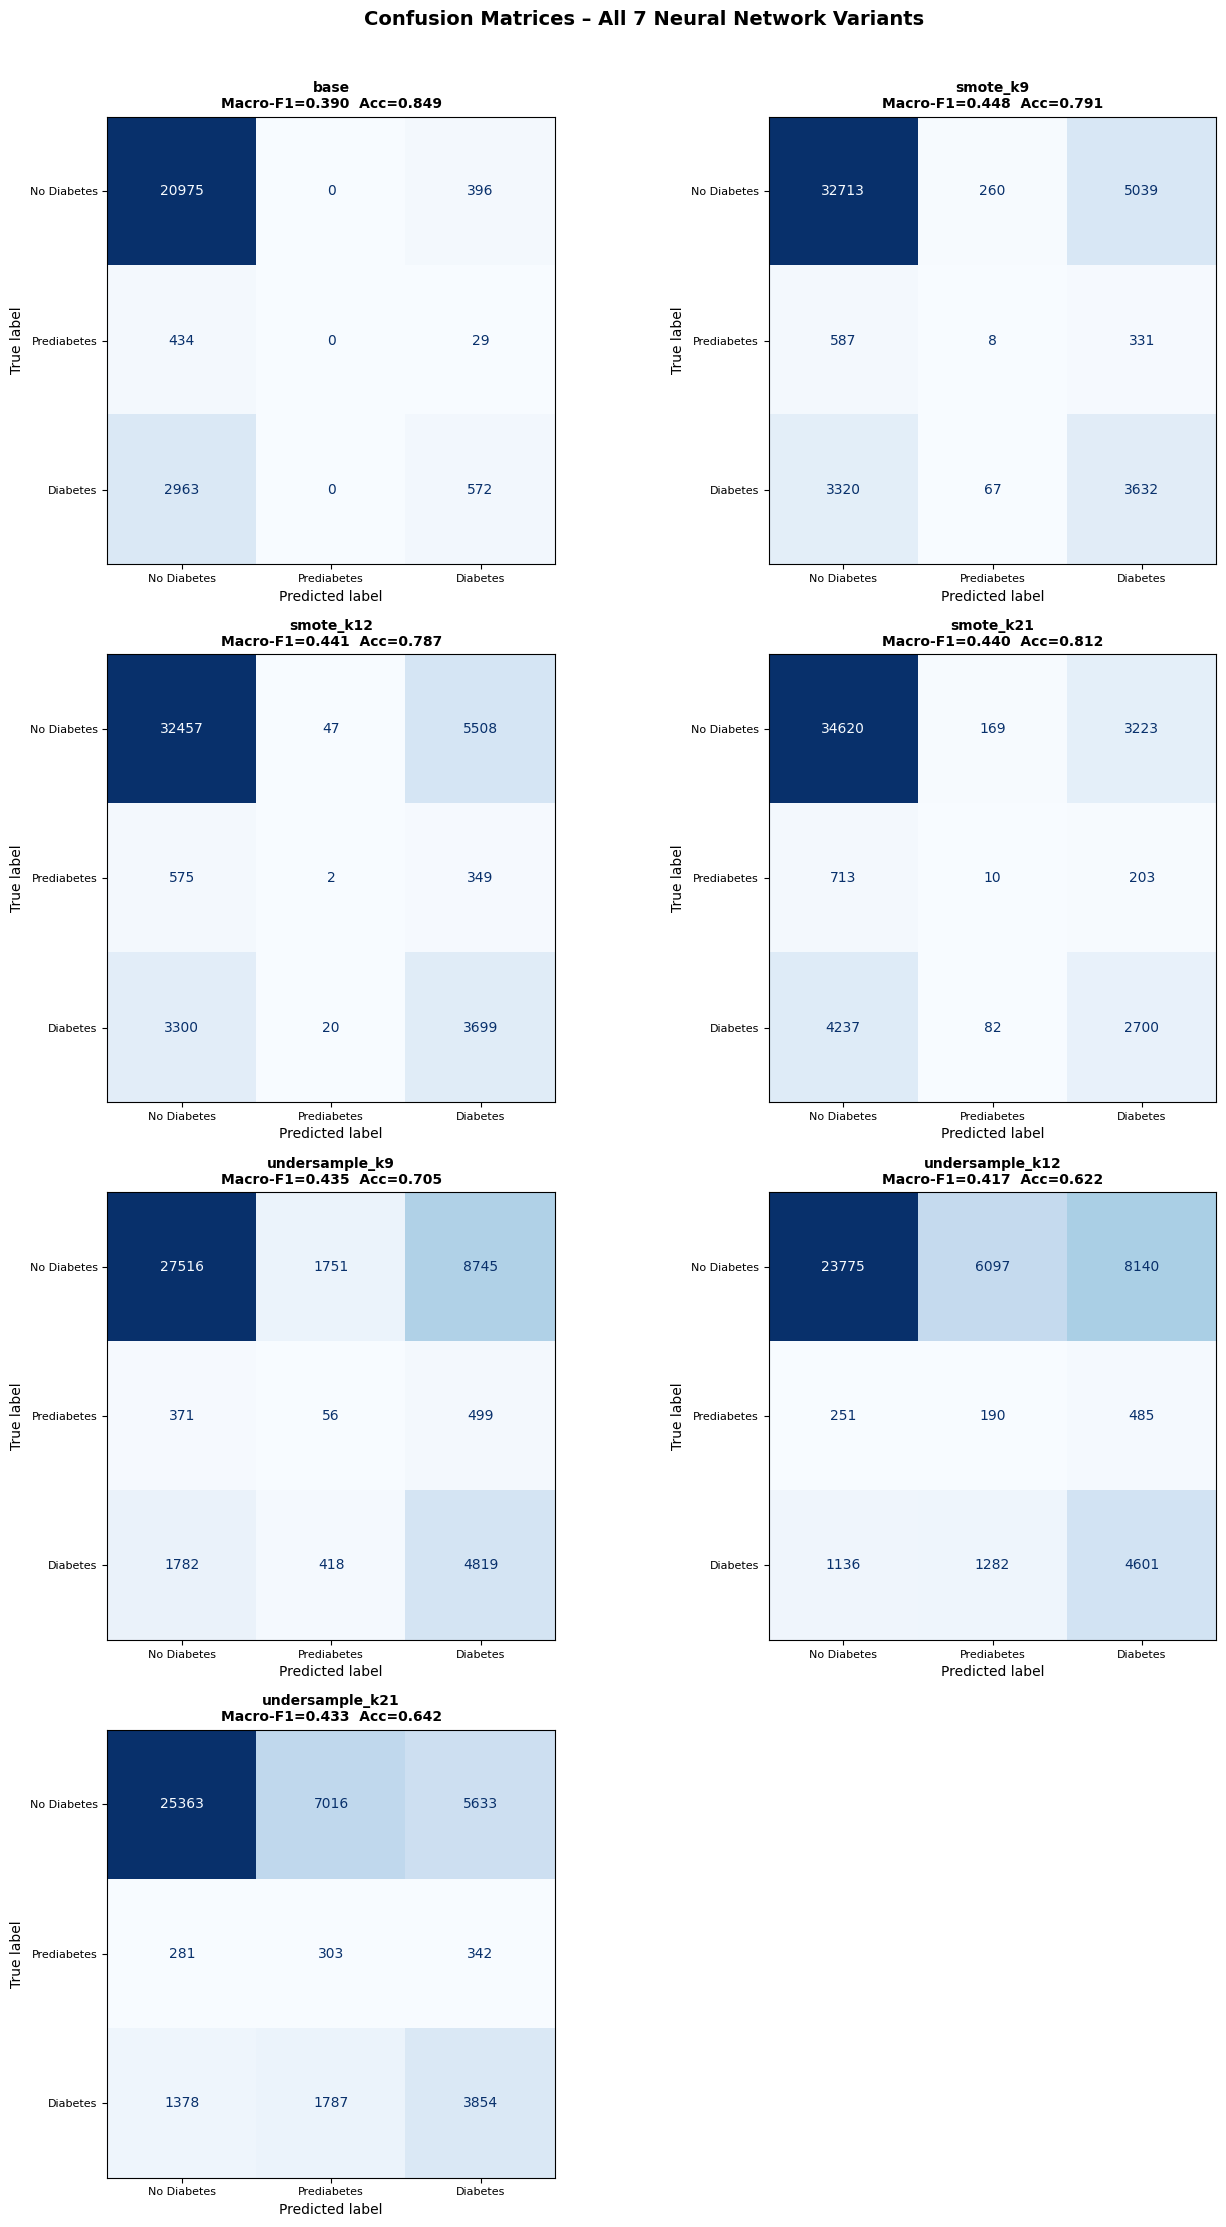

Saved → confusion_matrices_all_models.png


In [13]:
CLASS_NAMES = ["No Diabetes", "Prediabetes", "Diabetes"]

fig, axes = plt.subplots(4, 2, figsize=(14, 22))
axes = axes.flatten()

for ax, (name, res) in zip(axes, all_results.items()):
    cm   = res["cm"]
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
    disp.plot(cmap="Blues", ax=ax, colorbar=False)
    ax.set_title(f"{name}\nMacro-F1={res['f1_macro']:.3f}  Acc={res['accuracy']:.3f}",
                 fontsize=10, fontweight="bold")
    ax.tick_params(labelsize=8)

# Hide the unused 8th subplot (we have 7 models)
axes[-1].set_visible(False)

plt.suptitle("Confusion Matrices – All 7 Neural Network Variants",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("confusion_matrices_all_models.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → confusion_matrices_all_models.png")

## Metrics Comparison Table
Summary of all evaluation metrics across the 7 models.

In [14]:
rows = []
for name, res in all_results.items():
    rows.append({
        "Model"       : name,
        "Accuracy"    : f"{res['accuracy']:.4f}",
        "F1 Micro"    : f"{res['f1_micro']:.4f}",
        "F1 Macro"    : f"{res['f1_macro']:.4f}",
        "F1 Weighted" : f"{res['f1_weighted']:.4f}",
        "Precision(W)" : f"{res['precision_w']:.4f}",
        "Recall(W)"   : f"{res['recall_w']:.4f}",
    })

comparison_df = pd.DataFrame(rows).set_index("Model")
print(comparison_df.to_string())
comparison_df

                Accuracy F1 Micro F1 Macro F1 Weighted Precision(W) Recall(W)
Model                                                                        
base              0.8493   0.8493   0.3898      0.8077       0.8049    0.8493
smote_k9          0.7910   0.7910   0.4476      0.7946       0.8010    0.7910
smote_k12         0.7868   0.7868   0.4412      0.7905       0.7986    0.7868
smote_k21         0.8123   0.8123   0.4400      0.8013       0.7917    0.8123
undersample_k9    0.7048   0.7048   0.4353      0.7431       0.8199    0.7048
undersample_k12   0.6216   0.6216   0.4173      0.6929       0.8352    0.6216
undersample_k21   0.6423   0.6423   0.4326      0.7162       0.8369    0.6423


,Accuracy,F1 Micro,F1 Macro,F1 Weighted,Precision(W),Recall(W)
Model,,,,,,
base,0.8493,0.8493,0.3898,0.8077,0.8049,0.8493
smote_k9,0.7910,0.7910,0.4476,0.7946,0.8010,0.7910
smote_k12,0.7868,0.7868,0.4412,0.7905,0.7986,0.7868
smote_k21,0.8123,0.8123,0.4400,0.8013,0.7917,0.8123
undersample_k9,0.7048,0.7048,0.4353,0.7431,0.8199,0.7048
undersample_k12,0.6216,0.6216,0.4173,0.6929,0.8352,0.6216
undersample_k21,0.6423,0.6423,0.4326,0.7162,0.8369,0.6423


## Visual Comparison – F1 Scores
Bar chart comparing Micro, Macro, and Weighted F1 across all models.

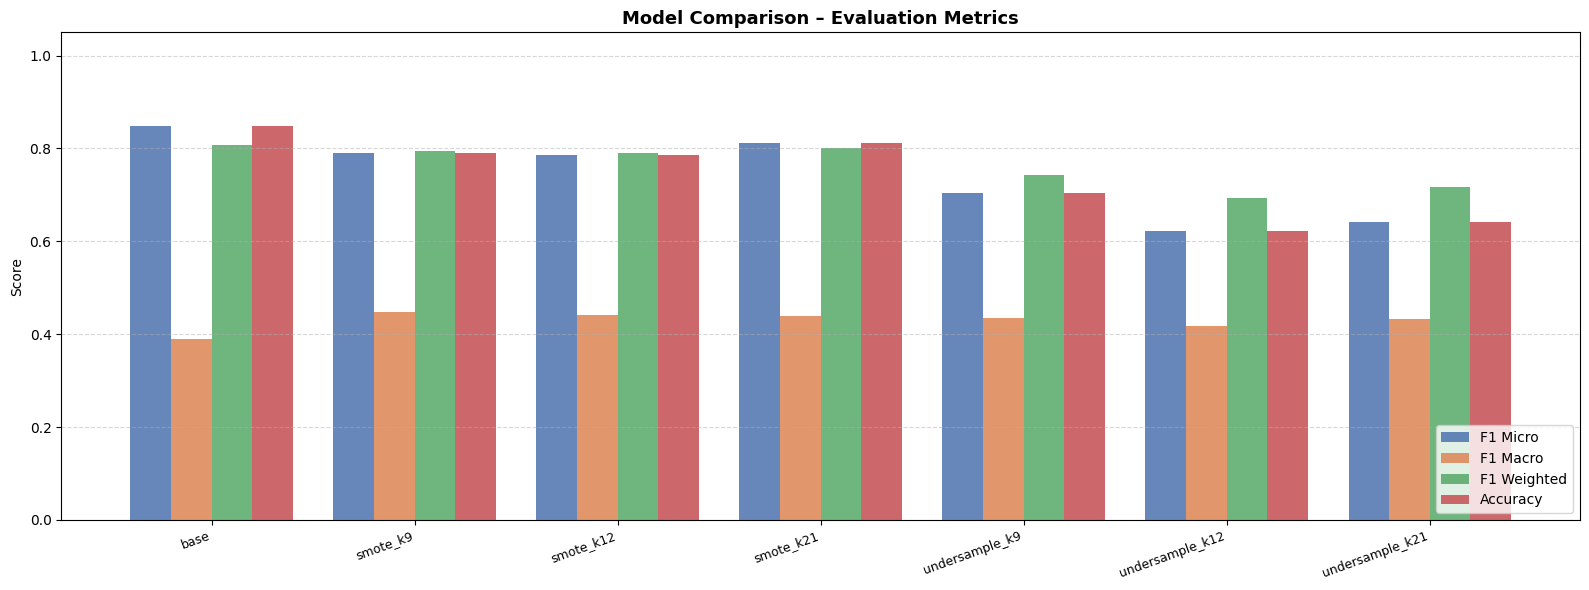

Saved → metrics_comparison_bar.png


In [15]:
metrics_to_plot = ["f1_micro", "f1_macro", "f1_weighted", "accuracy"]
metric_labels   = ["F1 Micro", "F1 Macro", "F1 Weighted", "Accuracy"]
colors          = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]

model_names = list(all_results.keys())
x = np.arange(len(model_names))
width = 0.2

fig, ax = plt.subplots(figsize=(16, 6))
for i, (metric, label, color) in enumerate(zip(metrics_to_plot, metric_labels, colors)):
    vals = [all_results[n][metric] for n in model_names]
    ax.bar(x + i * width, vals, width, label=label, color=color, alpha=0.85)

ax.set_xticks(x + 1.5 * width)
ax.set_xticklabels(model_names, rotation=20, ha="right", fontsize=9)
ax.set_ylim(0, 1.05)
ax.set_ylabel("Score")
ax.set_title("Model Comparison – Evaluation Metrics", fontsize=13, fontweight="bold")
ax.legend(loc="lower right")
ax.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig("metrics_comparison_bar.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → metrics_comparison_bar.png")

## Per-Class F1-Score Heatmap
Shows how well each model handles each class individually — critical for spotting Prediabetes performance.

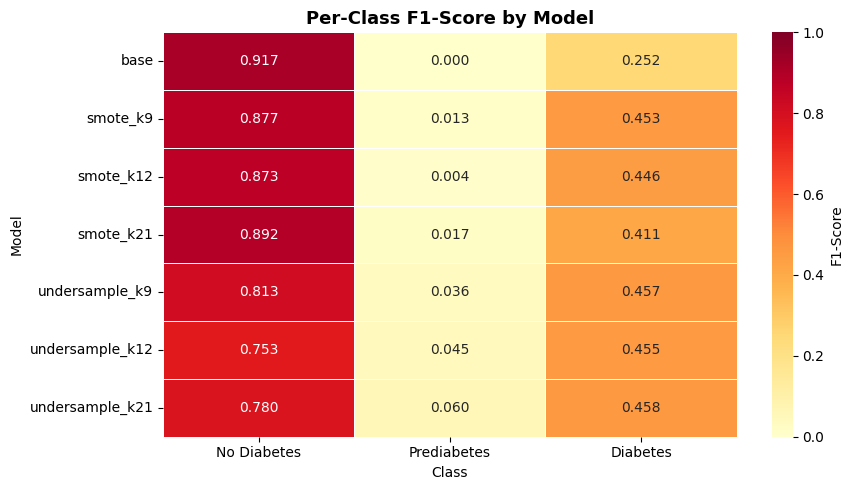

Saved → per_class_f1_heatmap.png


In [16]:
from sklearn.metrics import f1_score as sk_f1

per_class_f1 = {}
for name, res in all_results.items():
    per_class_f1[name] = sk_f1(res["y_test"], res["y_pred"],
                                average=None, labels=[0, 1, 2], zero_division=0)

heatmap_df = pd.DataFrame(per_class_f1, index=CLASS_NAMES).T

fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(heatmap_df, annot=True, fmt=".3f", cmap="YlOrRd",
            linewidths=0.5, ax=ax, vmin=0, vmax=1,
            cbar_kws={"label": "F1-Score"})
ax.set_title("Per-Class F1-Score by Model", fontsize=13, fontweight="bold")
ax.set_ylabel("Model")
ax.set_xlabel("Class")
plt.tight_layout()
plt.savefig("per_class_f1_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → per_class_f1_heatmap.png")

## TensorBoard

All 7 models log to separate sub-directories under `tensorboard_logs/`.  
Each run is named after the model (e.g. `tensorboard_logs/smote_k12/`).

Launch TensorBoard and compare training/validation loss curves side-by-side:
```
%tensorboard --logdir tensorboard_logs
```
Use the **Runs** selector (top-left) to toggle individual models on/off.


In [17]:
# List all available TensorBoard run directories
import os
tb_root = Path("tensorboard_logs")
if tb_root.exists():
    runs = sorted([p.name for p in tb_root.iterdir() if p.is_dir()])
    print(f"Found {len(runs)} TensorBoard run(s):")
    for r in runs:
        print(f"  {tb_root / r}")
else:
    print("No TensorBoard logs found yet — run the training cell first.")

Found 7 TensorBoard run(s):
  tensorboard_logs/base
  tensorboard_logs/smote_k12
  tensorboard_logs/smote_k21
  tensorboard_logs/smote_k9
  tensorboard_logs/undersample_k12
  tensorboard_logs/undersample_k21
  tensorboard_logs/undersample_k9


In [18]:
%load_ext tensorboard
%tensorboard --logdir tensorboard_logs